# Первичный анализ данных
Рассмотрим датасет `products_raw.csv`, полученный с помощью браузерного расширения MarketNinja. Датасет представляет из себя информацию о карточках товаров на Wildberries из категории "Мужские кеды/кроссовки". В рамках одной категории товаров легче сравнивать карточки и находить зависимости в обучении, в дальнейшем этот метод можно переложить и на другие категории товаров.

In [1]:
# Импортируем необходимые библиотеки и настраиваем графики, 
# это не комментарий llm, это я написал
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

PALETTE = {
    "primary": "#20808D",
    "secondary": "#A84B2F",
    "dark": "#1B474D",
    "muted": "#7A7974",
    "positive": "#437A22",
    "negative": "#A13544",
}

## 1. Содержимое датасета
Рассмотрим из чего состоит датасет, сколько в нем данных и как называются колонки.

In [7]:
DATA_PATH = "../data/raw/products.csv"
df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"Названия колонок: {df.columns}")

Размер датасета: 4861 строк, 41 колонок
Названия колонок: Index(['Артикул', 'Артикул поставщика', 'Бренд', 'Название', 'Категория',
       'Спец. цена', 'Цена', 'Старая цена', 'Скидка', 'Цвет', 'Размер',
       'Реклама', 'Продавец', 'ID продавца', 'Рейтинг продавца',
       'Отзывы продавца', 'Зарегистрирован', 'Возраст магазина',
       'Продажи продавца', 'Процент выкупа', 'Юр. лицо', 'ИНН',
       'ОГРН / ОГРНИП', 'Адрес продавца', 'Страница продавца', 'Фулфилмент',
       'Доставка', 'Рейтинг', 'Оценок', 'Оплата за отзыв', 'Сезон',
       'Название размера', 'Кол-во картинок', 'URL', 'Картинка', 'Галерея',
       'Видеообложка', 'Описание', 'Rich-контент', 'Состав',
       'Страна производства'],
      dtype='str')


In [8]:
display(df.head(3))
display(df.sample(3, random_state=RANDOM_SEED))

,Артикул,Артикул поставщика,Бренд,Название,Категория,Спец. цена,Цена,Старая цена,Скидка,Цвет,...,Название размера,Кол-во картинок,URL,Картинка,Галерея,Видеообложка,Описание,Rich-контент,Состав,Страна производства
0,144542463,1150000013,X-Plode,Летние кеды тканевые дышащие,Обувь / Кеды,1461.0,1491,3888.0,61.0,"серый, белый",...,40;41;42;43;44;45;46;39;47;48,10,https://www.wildberries.ru/catalog/144542463/d...,https://basket-10.wbbasket.ru/vol1445/part1445...,https://basket-10.wbbasket.ru/vol1445/part1445...,https://videonme-basket-02.wbbasket.ru/vol15/p...,Низкие кеды — универсальная повседневная обувь...,Да,текстиль,Гонконг
1,204459429,C3549-1,Strobbs,Кеды мужские весенние,Обувь / Кеды,5639.0,5755,11990.0,52.0,серый,...,41;42;43;44;45;38;39;40,10,https://www.wildberries.ru/catalog/204459429/d...,https://basket-13.wbbasket.ru/vol2044/part2044...,https://basket-13.wbbasket.ru/vol2044/part2044...,NaN,Характеристики / преимущества • Вес полупарки...,Да,микрофибра; текстиль,Китай
2,65828833,12822215/1150221017,X-Plode,Джинсовые летние кеды тканевые,Обувь / Кеды,1206.0,1231,3210.0,61.0,"синий, белый",...,40;41;42;43;44;45;46;39;47;48,10,https://www.wildberries.ru/catalog/65828833/de...,https://basket-04.wbbasket.ru/vol658/part65828...,https://basket-04.wbbasket.ru/vol658/part65828...,https://videonme-basket-09.wbbasket.ru/vol97/p...,Низкие кеды — универсальная повседневная обувь...,Да,текстиль,Гонконг


,Артикул,Артикул поставщика,Бренд,Название,Категория,Спец. цена,Цена,Старая цена,Скидка,Цвет,...,Название размера,Кол-во картинок,URL,Картинка,Галерея,Видеообложка,Описание,Rich-контент,Состав,Страна производства
2186,897794213,LH282-11,NaN,Мужские кроссовки летние,Обувь / Кеды,4572.0,4666,6045.0,22.0,черный,...,"40(25,5cm);41(26cm);42(26,5cm);43(27CM);44(27,...",18,https://www.wildberries.ru/catalog/897794213/d...,https://basket-39.wbbasket.ru/vol8977/part8977...,https://basket-39.wbbasket.ru/vol8977/part8977...,NaN,Представляем вам обновлённые кеды из натуральн...,Нет,натуральная кожа,Китай
3351,946646694,LH207-4AA6,LUXEONARY,Кеды белые демисезонные натуральная кожа,Обувь / Кеды,5477.0,5589,6987.0,20.0,белый,...,"40(25,5cm);42(26,5cm);43(27CM);45(28CM)",10,https://www.wildberries.ru/catalog/946646694/d...,https://basket-40.wbbasket.ru/vol9466/part9466...,https://basket-40.wbbasket.ru/vol9466/part9466...,NaN,Кеды Luxeonary в белом цвете — это стильная му...,Нет,натуральная кожа; резина,Китай
2651,617687808,GH7602-11-adcmNanxie005,NaN,Кеды черные замшевые с белой подошвой для работы,Обувь / Кеды,4237.0,4324,13285.0,67.0,черный,...,43;44;45;40;41;42,10,https://www.wildberries.ru/catalog/617687808/d...,https://basket-31.wbbasket.ru/vol6176/part6176...,https://basket-31.wbbasket.ru/vol6176/part6176...,NaN,Представляем мужские кроссовки модель GH7602-1...,Нет,натуральная кожа; Формованная подошва; резинов...,Китай


Всего в датасете 41 колонка, можем разделить их на следующие группы по смыслу:
- идентификаторы товара: `Артикул`, `Артикул поставщика`, `URL`;
- признаки карточки: `Бренд`, `Название`, `Категория`, `Цвет`, `Размер`, `Сезон`, `Описание`, `Состав`, `Страна производства`;
- цена и скидки: `Спец. цена`, `Цена`, `Старая цена`, `Скидка`;
- визуальное оформление: `Кол-во картинок`, `Галерея`, `Видеообложка`, `Rich-контент`;
- признаки продавца: `Продавец`, `Фулфилмент`, `Доставка`;
- премиум-поля (скрыты без подписки): `ID продавца`, `Рейтинг продавца`, `Отзывы продавца` и т.д.;
- прокси-метрики: `Рейтинг`, `Оценок`.

Прокси-метрики отражают успешность карточки на маркетплейсе, потенциально из них мы будем получать таргет-метрику.

In [9]:
schema = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_count": [int(df[c].isna().sum()) for c in df.columns],
    "missing_rate": [round(df[c].isna().mean(), 4) for c in df.columns],
    "nunique": [int(df[c].nunique(dropna=True)) for c in df.columns],
})
schema

,column,dtype,missing_count,missing_rate,nunique
0,Артикул,int64,0,0.0000,4861
1,Артикул поставщика,str,0,0.0000,4064
2,Бренд,str,1744,0.3588,306
3,Название,str,0,0.0000,1740
4,Категория,str,0,0.0000,2
5,Спец. цена,float64,32,0.0066,1904
6,Цена,int64,0,0.0000,1944
7,Старая цена,float64,30,0.0062,1262
8,Скидка,float64,38,0.0078,89
9,Цвет,str,12,0.0025,94


## 2. Качество датасета
Проверим датасет на наличие дубликатов, пропусков, пустых/скрытых колонок. 

In [10]:
quality_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "duplicates",
        "missing_cells_total",
        "missing_cells_share",
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        int(df.duplicated().sum()),
        int(df.isna().sum().sum()),
        round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]), 4),
    ],
})
quality_summary

,metric,value
0,rows,4861.0000
1,columns,41.0000
2,duplicates,0.0000
3,missing_cells_total,18606.0000
4,missing_cells_share,0.0934


In [11]:
missing_stats = (
    df.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "column"})
)
missing_stats["missing_pct"] = (missing_stats["missing_rate"] * 100).round(2)
missing_stats.head(20)

,column,missing_rate,missing_pct
0,Оплата за отзыв,0.988480,98.85
1,Видеообложка,0.880477,88.05
2,Оценок,0.699856,69.99
3,Рейтинг,0.699856,69.99
4,Бренд,0.358774,35.88
5,Страна производства,0.067270,6.73
6,Сезон,0.056984,5.70
7,Состав,0.029006,2.90
8,Описание,0.019132,1.91
9,Скидка,0.007817,0.78


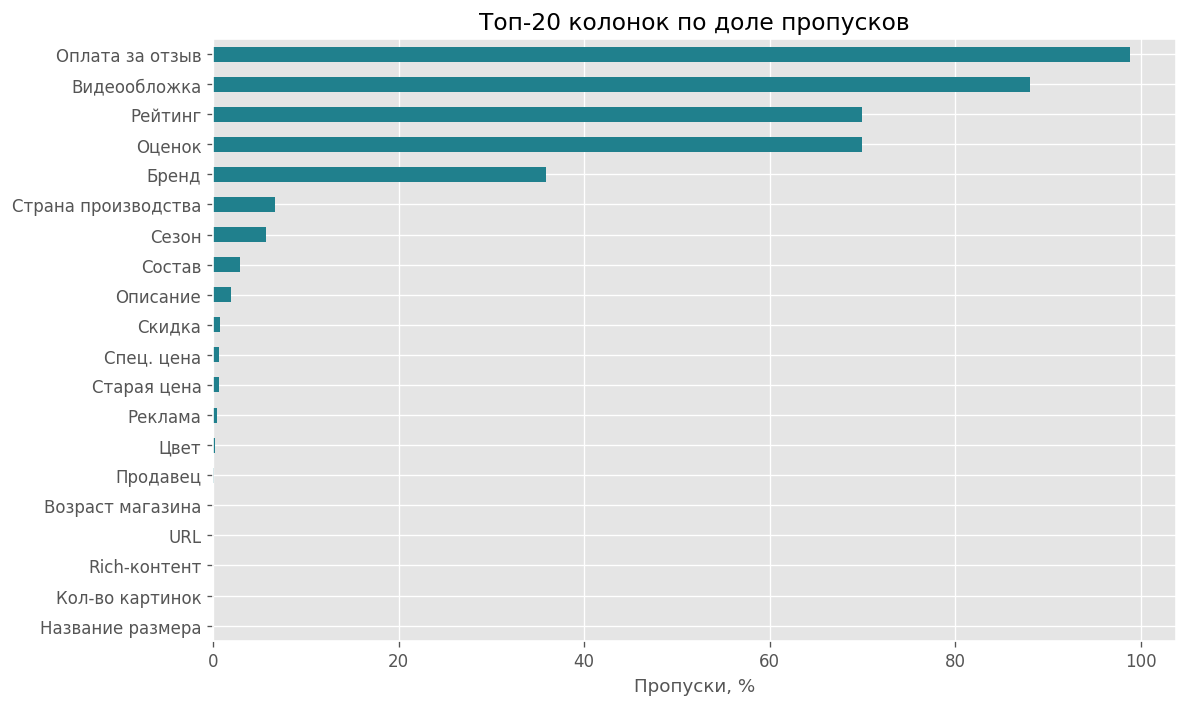

In [12]:
plot_df = missing_stats.sort_values("missing_pct", ascending=True).tail(20)
ax = plot_df.plot(
    kind="barh",
    x="column",
    y="missing_pct",
    legend=False,
    color=PALETTE["primary"],
    title="Топ-20 колонок по доле пропусков",
)
ax.set_xlabel("Пропуски, %")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Как мы видим по графику, колонки `Рейтинг` и `Оценок` заполнены только у части товаров, следовательно не все строки имеют необходимые прокси-метрики для расчёта таргета.

Колонка `Видеообложка` почти пустая, но это означает отсутствие видео, поэтому ее можно представлять в бинарной кодировке `0` - нет видео, `1` - есть видео.

Колонка `Оплата за отзыв` самая пустая колонка из всех, поэтому ее можно считать лишней информацией в датасете.

Колонки, связанные с продавцами, скрыты, т.к. для сбора таких данных необходима подписка на браузерное расширение.

## 3. Нормализация данных, добавление новых признаков для анализа
Для анализа мы можем добавить следующие признаки:

- длина названия;
- длина описания;
- число слов в описании;
- есть ли бренд;
- есть ли страна производства;
- есть ли видео;
- есть ли rich-контент;
- расчётная скидка;
- логарифмы цены и количества оценок.

Длину текста и число слов мы можем оценивать как простые признаки полноты карточки.

In [13]:
def yes_no_to_int(series: pd.Series) -> pd.Series:
    return series.map({"Да": 1, "Нет": 0}).astype("float")


eda_df = df.copy()

eda_df["name_len"] = eda_df["Название"].fillna("").astype(str).str.len()
eda_df["name_word_count"] = eda_df["Название"].fillna("").astype(str).str.split().str.len()
eda_df["description_len"] = eda_df["Описание"].fillna("").astype(str).str.len()
eda_df["description_word_count"] = eda_df["Описание"].fillna("").astype(str).str.split().str.len()
eda_df["description_missing"] = eda_df["Описание"].isna().astype(int)
eda_df["has_brand"] = eda_df["Бренд"].notna().astype(int)
eda_df["has_country"] = eda_df["Страна производства"].notna().astype(int)
eda_df["has_video"] = eda_df["Видеообложка"].notna().astype(int)
eda_df["has_rich_content"] = yes_no_to_int(eda_df["Rich-контент"]).fillna(0).astype(int)
eda_df["is_ad"] = yes_no_to_int(eda_df["Реклама"])

eda_df["price_log1p"] = np.log1p(eda_df["Цена"].clip(lower=0))
eda_df["special_price_log1p"] = np.log1p(eda_df["Спец. цена"].clip(lower=0))
eda_df["discount_ratio_calc"] = np.where(
    eda_df["Старая цена"].fillna(0) > 0,
    (eda_df["Старая цена"] - eda_df["Цена"]) / eda_df["Старая цена"],
    np.nan,
)

eda_features = [
    "name_len", "name_word_count", "description_len", "description_word_count",
    "description_missing", "has_brand", "has_country", "has_video",
    "has_rich_content", "is_ad", "price_log1p", "special_price_log1p",
    "discount_ratio_calc",
]

eda_df[eda_features].describe().T

,count,mean,std,min,25%,50%,75%,max
name_len,4861.0,34.115820,12.852277,4.000000,25.000000,34.000000,43.000000,61.000000
name_word_count,4861.0,4.642049,1.729029,1.000000,3.000000,4.000000,6.000000,10.000000
description_len,4861.0,1146.432833,486.937940,0.000000,807.000000,1155.000000,1558.000000,2000.000000
description_word_count,4861.0,153.164987,65.425300,0.000000,108.000000,151.000000,204.000000,317.000000
description_missing,4861.0,0.019132,0.137003,0.000000,0.000000,0.000000,0.000000,1.000000
has_brand,4861.0,0.641226,0.479690,0.000000,0.000000,1.000000,1.000000,1.000000
has_country,4861.0,0.932730,0.250515,0.000000,1.000000,1.000000,1.000000,1.000000
has_video,4861.0,0.119523,0.324436,0.000000,0.000000,0.000000,0.000000,1.000000
has_rich_content,4861.0,0.059041,0.235726,0.000000,0.000000,0.000000,0.000000,1.000000
is_ad,4841.0,0.044619,0.206487,0.000000,0.000000,0.000000,0.000000,1.000000


## 4. Числовые признаки
Проанализируем распределение цены, скидки, количества картинок, рейтинга и оценок для карточек.

При этом:
- цена, скидка количество картинок используються для обучения модели
- рейтинг, оценки составляют таргет-метрику

In [14]:
numeric_cols = ["Спец. цена", "Цена", "Старая цена", "Скидка", "Кол-во картинок", "Рейтинг", "Оценок"]

numeric_profile = []
for col in numeric_cols:
    s = eda_df[col].dropna()
    numeric_profile.append({
        "column": col,
        "count": int(s.shape[0]),
        "mean": round(s.mean(), 3),
        "median": round(s.median(), 3),
        "std": round(s.std(), 3),
        "min": round(s.min(), 3),
        "p1": round(s.quantile(0.01), 3),
        "p5": round(s.quantile(0.05), 3),
        "p25": round(s.quantile(0.25), 3),
        "p75": round(s.quantile(0.75), 3),
        "p95": round(s.quantile(0.95), 3),
        "p99": round(s.quantile(0.99), 3),
        "max": round(s.max(), 3),
    })

pd.DataFrame(numeric_profile)

,column,count,mean,median,std,min,p1,p5,p25,p75,p95,p99,max
0,Спец. цена,4829,4240.293,4319.0,1415.799,999.0,1338.84,1801.8,3485.0,4858.0,6535.8,8124.0,13212.0
1,Цена,4861,4319.241,4405.0,1465.983,1020.0,1367.80,1820.0,3514.0,4956.0,6665.0,8290.0,20193.0
2,Старая цена,4831,10187.643,9000.0,4741.311,1493.0,3021.00,4774.0,7000.0,13202.5,17240.0,22962.0,100000.0
3,Скидка,4823,52.435,58.0,18.426,5.0,7.00,20.0,38.0,68.0,75.0,85.0,96.0
4,Кол-во картинок,4861,11.687,10.0,4.548,1.0,1.00,5.0,9.0,15.0,20.0,23.0,30.0
5,Рейтинг,1459,4.767,4.8,0.199,3.5,4.20,4.4,4.6,4.9,5.0,5.0,5.0
6,Оценок,1459,184.869,37.0,617.987,1.0,1.00,1.0,9.0,138.0,766.2,2065.0,11726.0


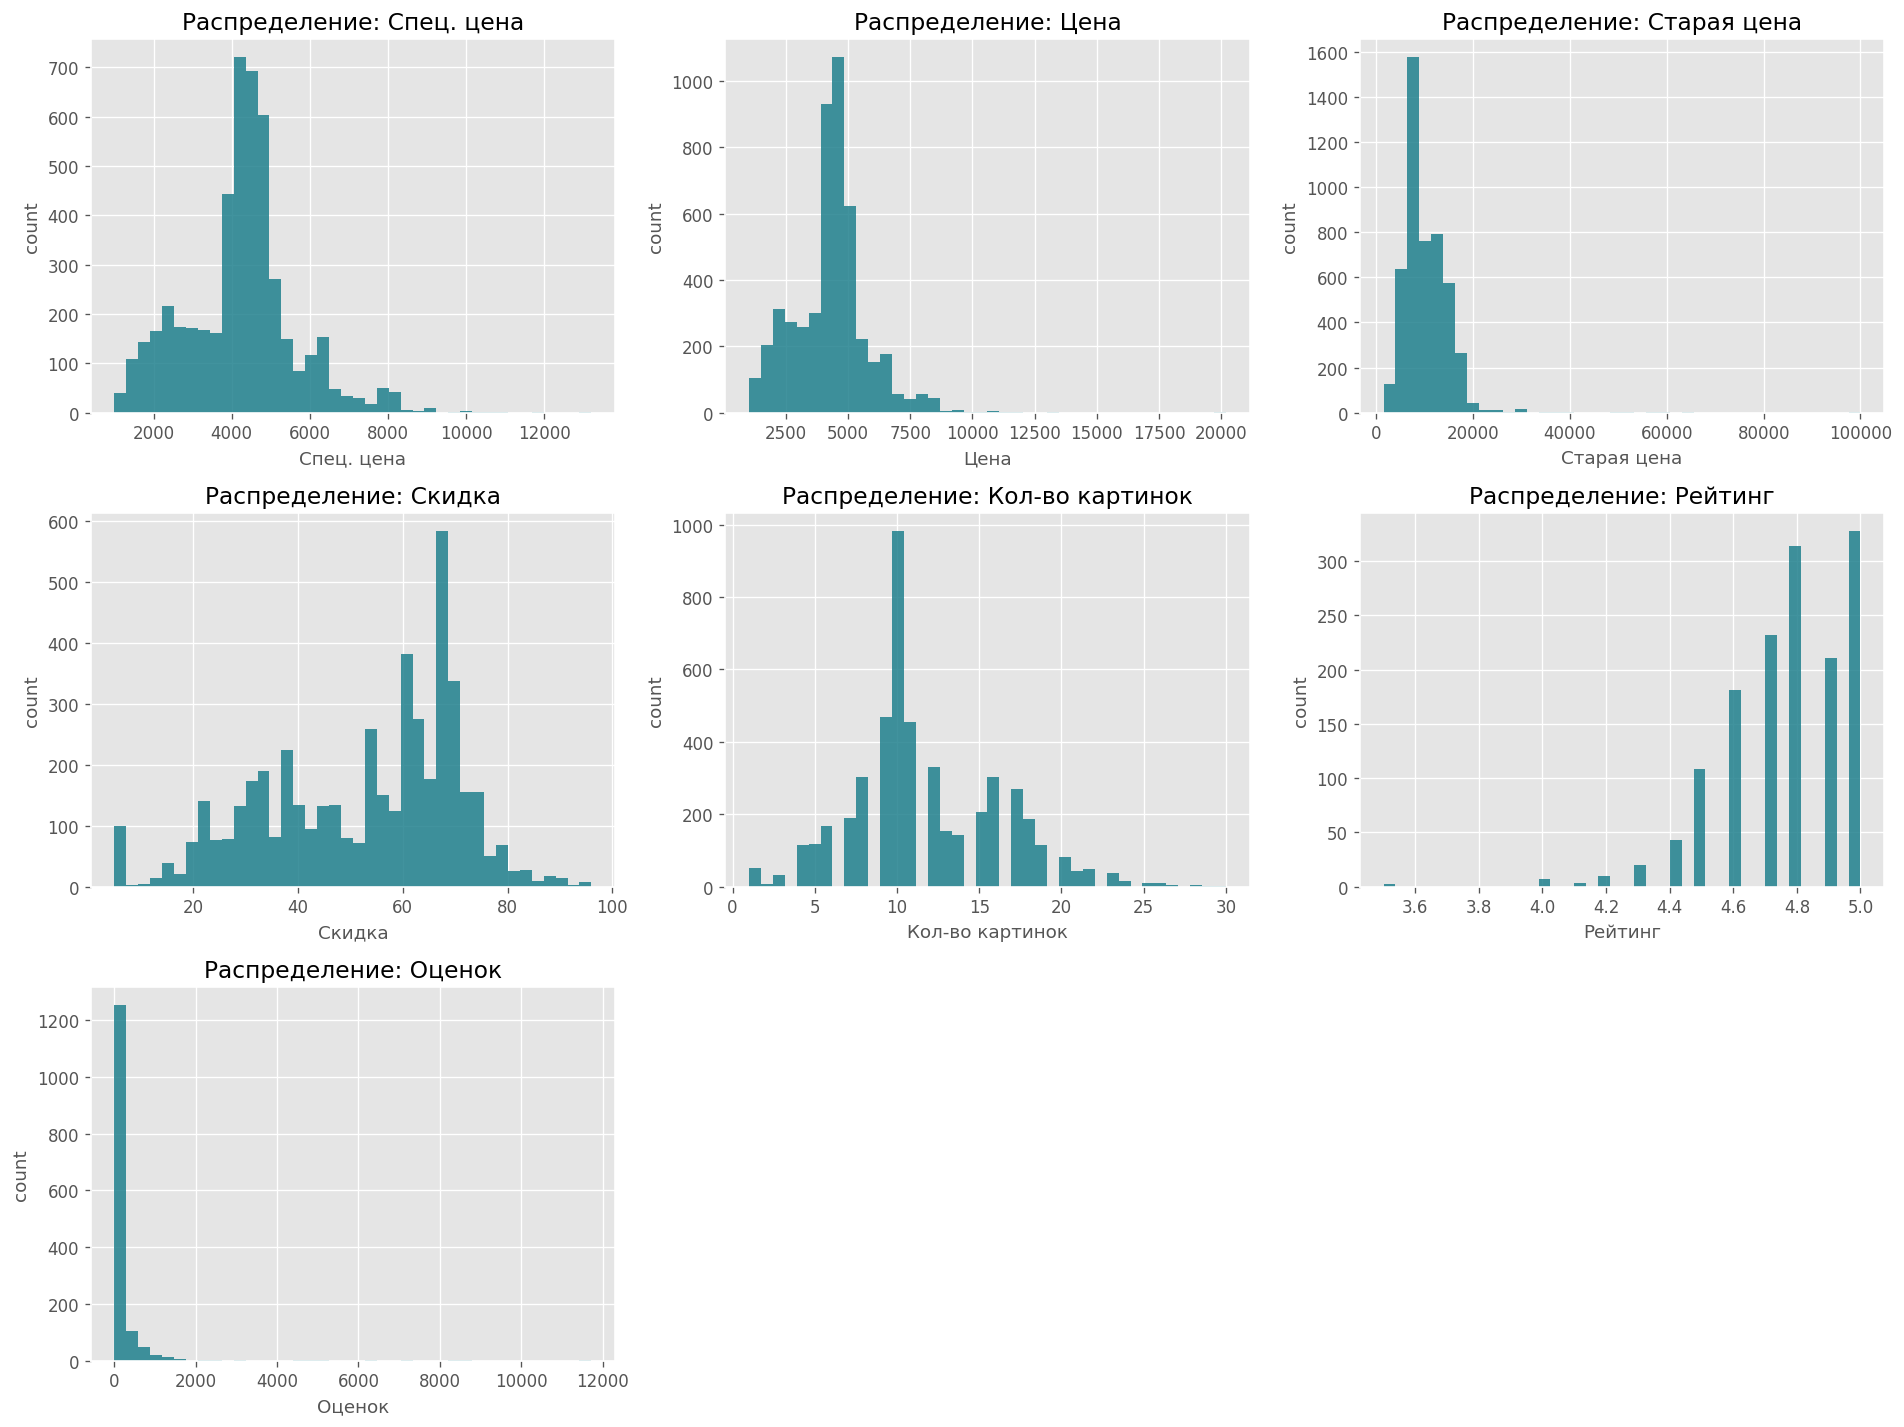

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    s = eda_df[col].dropna()
    axes[i].hist(s, bins=40, color=PALETTE["primary"], alpha=0.85)
    axes[i].set_title(f"Распределение: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("count")

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Мы можем сделать следующий вывод по полученным данным:

- `Оценок` имеет тяжёлый хвост: у части карточек очень много оценок. Поэтому для формирования таргета будем использовать `log1p(Оценок)`, а не первоначальное значение.
- `Рейтинг` лежит в диапазоне 1-5, но он может быть только у товаров с оценками.
- `Кол-во картинок` используем как признак полноты карточки
- `Старая цена` содержит неравномерные значения, поэтому надо использовать логарифмирование или обработку выбросов.

## 5. Формирование таргет-метрики
Таргет построим через прокси-метрики, которые показывают успешность карточки, т.е. будем использовать следующие поля:

- `Рейтинг`: показывает среднюю оценку товара;
- `Оценок`: показывает, насколько эта оценка подтверждена пользователями.

Количество оценок показывает, насколько рейтинг валиден, т.к. товар с рейтингом 5.0 и 1 оценкой необязательно будет более успешен товара с рейтингом 4.8 и 1000 оценок.

Формула:

`rating_norm = (Рейтинг - 1) / 4`

`reviews_log_norm = log1p(Оценок) / log1p(max(Оценок))`

`success_proxy_score = 0.65 * rating_norm + 0.35 * reviews_log_norm`

Это будет таргет-метрика для нашей задачи регрессии.

Стоит заметить, что не все строки имеют необходимые прокси-метрики, поэтому к сожалению мы не можем оценить их успешность, т.к. нам не хватает данных. Эти строки учитывать не будем.

In [16]:
target_df = eda_df.copy()

target_df["rating_norm"] = (target_df["Рейтинг"] - 1) / 4
target_df["reviews_log1p"] = np.log1p(target_df["Оценок"])
target_df["reviews_log_norm"] = target_df["reviews_log1p"] / np.log1p(target_df["Оценок"].max())

target_df["success_proxy_score"] = (
    0.65 * target_df["rating_norm"]
    + 0.35 * target_df["reviews_log_norm"]
)

target_is_available = target_df["success_proxy_score"].notna()

print(f"Строк всего: {len(target_df)}")
print(f"Строк с регрессионным proxy target: {target_is_available.sum()}")
print(f"Строк без proxy target: {(~target_is_available).sum()}")

target_df.loc[target_is_available, "success_proxy_score"].describe()

Строк всего: 4861
Строк с регрессионным proxy target: 1459
Строк без proxy target: 3402


count    1459.000000
mean        0.748796
std         0.065581
min         0.447288
25%         0.701785
50%         0.748111
75%         0.795676
max         0.954354
Name: success_proxy_score, dtype: float64

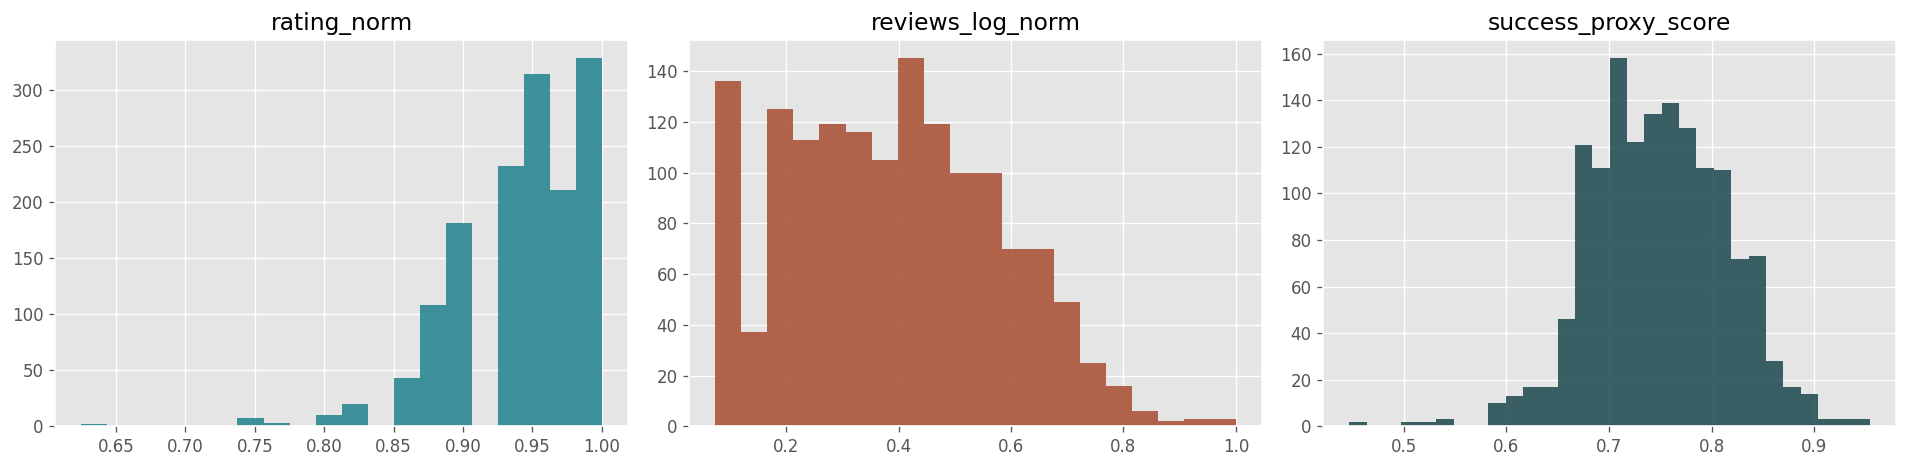

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

target_df.loc[target_is_available, "rating_norm"].hist(bins=20, ax=axes[0], color=PALETTE["primary"], alpha=0.85)
axes[0].set_title("rating_norm")

target_df.loc[target_is_available, "reviews_log_norm"].hist(bins=20, ax=axes[1], color=PALETTE["secondary"], alpha=0.85)
axes[1].set_title("reviews_log_norm")

target_df.loc[target_is_available, "success_proxy_score"].hist(bins=30, ax=axes[2], color=PALETTE["dark"], alpha=0.85)
axes[2].set_title("success_proxy_score")

plt.tight_layout()
plt.show()

## 6. Зависимости признаков карточки от таргет-метрики

Изучим зависимости формата "признак vs таргет", чтобы понять, какие признаки коррелируеют с таргет-метрикой и могут быть полезны для обучения. 

Признаки, являющиеся частью таргет-метрики мы не используем в обучении, чтобы не допустить даталик.

С этого момента мы будем работать только со строками, у которых известна таргет-метрика.

In [18]:
supervised_df = target_df[target_df["success_proxy_score"].notna()].copy()

print("Размер полезной части:", supervised_df.shape)
display(supervised_df["success_proxy_score"].describe().to_frame("success_proxy_score"))

Размер полезной части: (1459, 58)


,success_proxy_score
count,1459.000000
mean,0.748796
std,0.065581
min,0.447288
25%,0.701785
50%,0.748111
75%,0.795676
max,0.954354


In [19]:
safe_numeric_features = [
    "Цена",
    "Спец. цена",
    "Старая цена",
    "Скидка",
    "Кол-во картинок",
    "name_len",
    "name_word_count",
    "description_len",
    "description_word_count",
    "description_missing",
    "has_brand",
    "has_country",
    "has_video",
    "has_rich_content",
    "is_ad",
    "discount_ratio_calc",
    "price_log1p",
    "special_price_log1p",
]

feature_corr = (
    supervised_df[safe_numeric_features + ["success_proxy_score"]]
    .corr(numeric_only=True)["success_proxy_score"]
    .drop("success_proxy_score")
    .sort_values(ascending=False)
)

feature_corr.to_frame("corr_with_success_proxy_score")

,corr_with_success_proxy_score
Кол-во картинок,0.289179
has_rich_content,0.264909
has_video,0.213338
is_ad,0.170895
name_word_count,0.121238
name_len,0.118830
description_len,0.102740
description_word_count,0.099844
has_brand,0.073956
has_country,0.054615


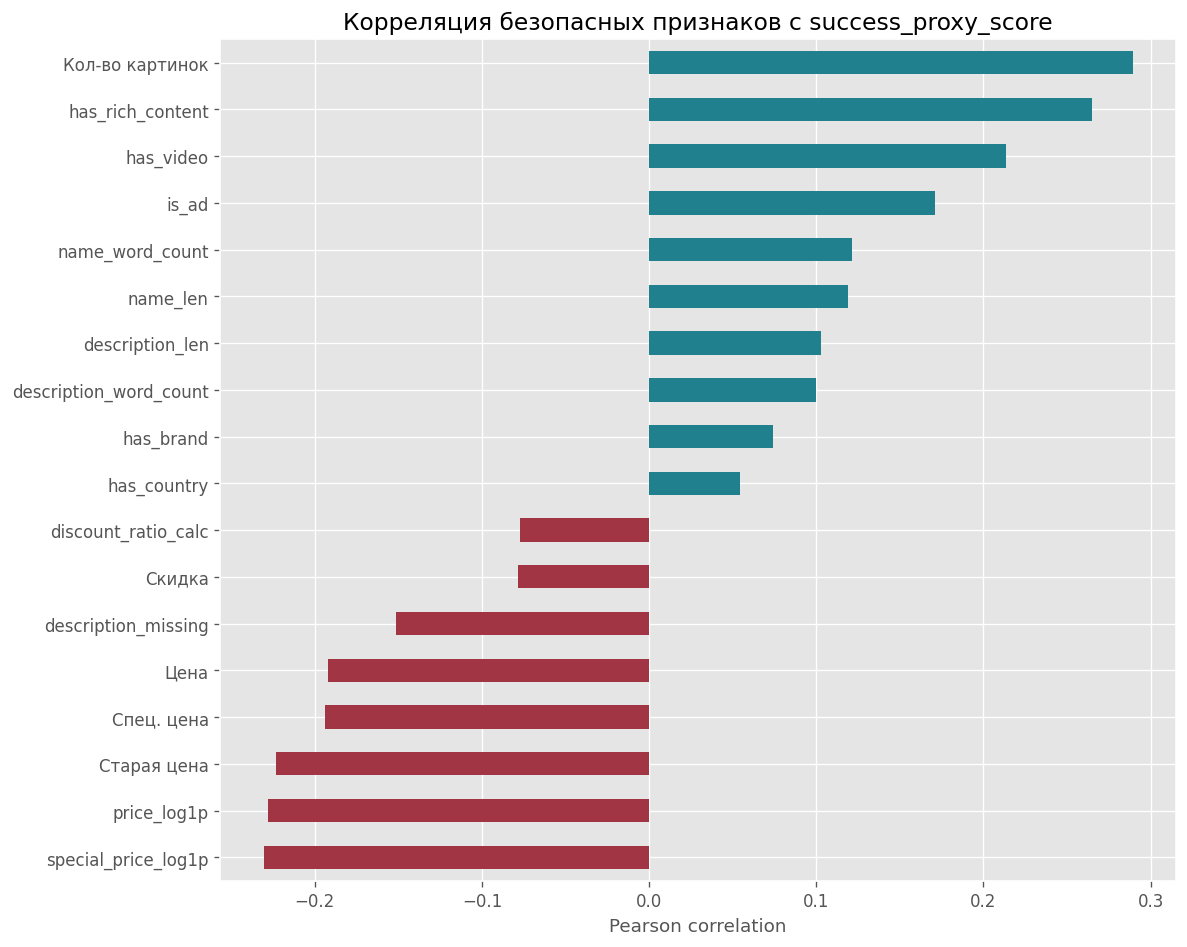

In [20]:
ax = feature_corr.sort_values().plot(
    kind="barh",
    figsize=(10, 8),
    color=[PALETTE["negative"] if v < 0 else PALETTE["primary"] for v in feature_corr.sort_values()],
    title="Корреляция безопасных признаков с success_proxy_score",
)
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

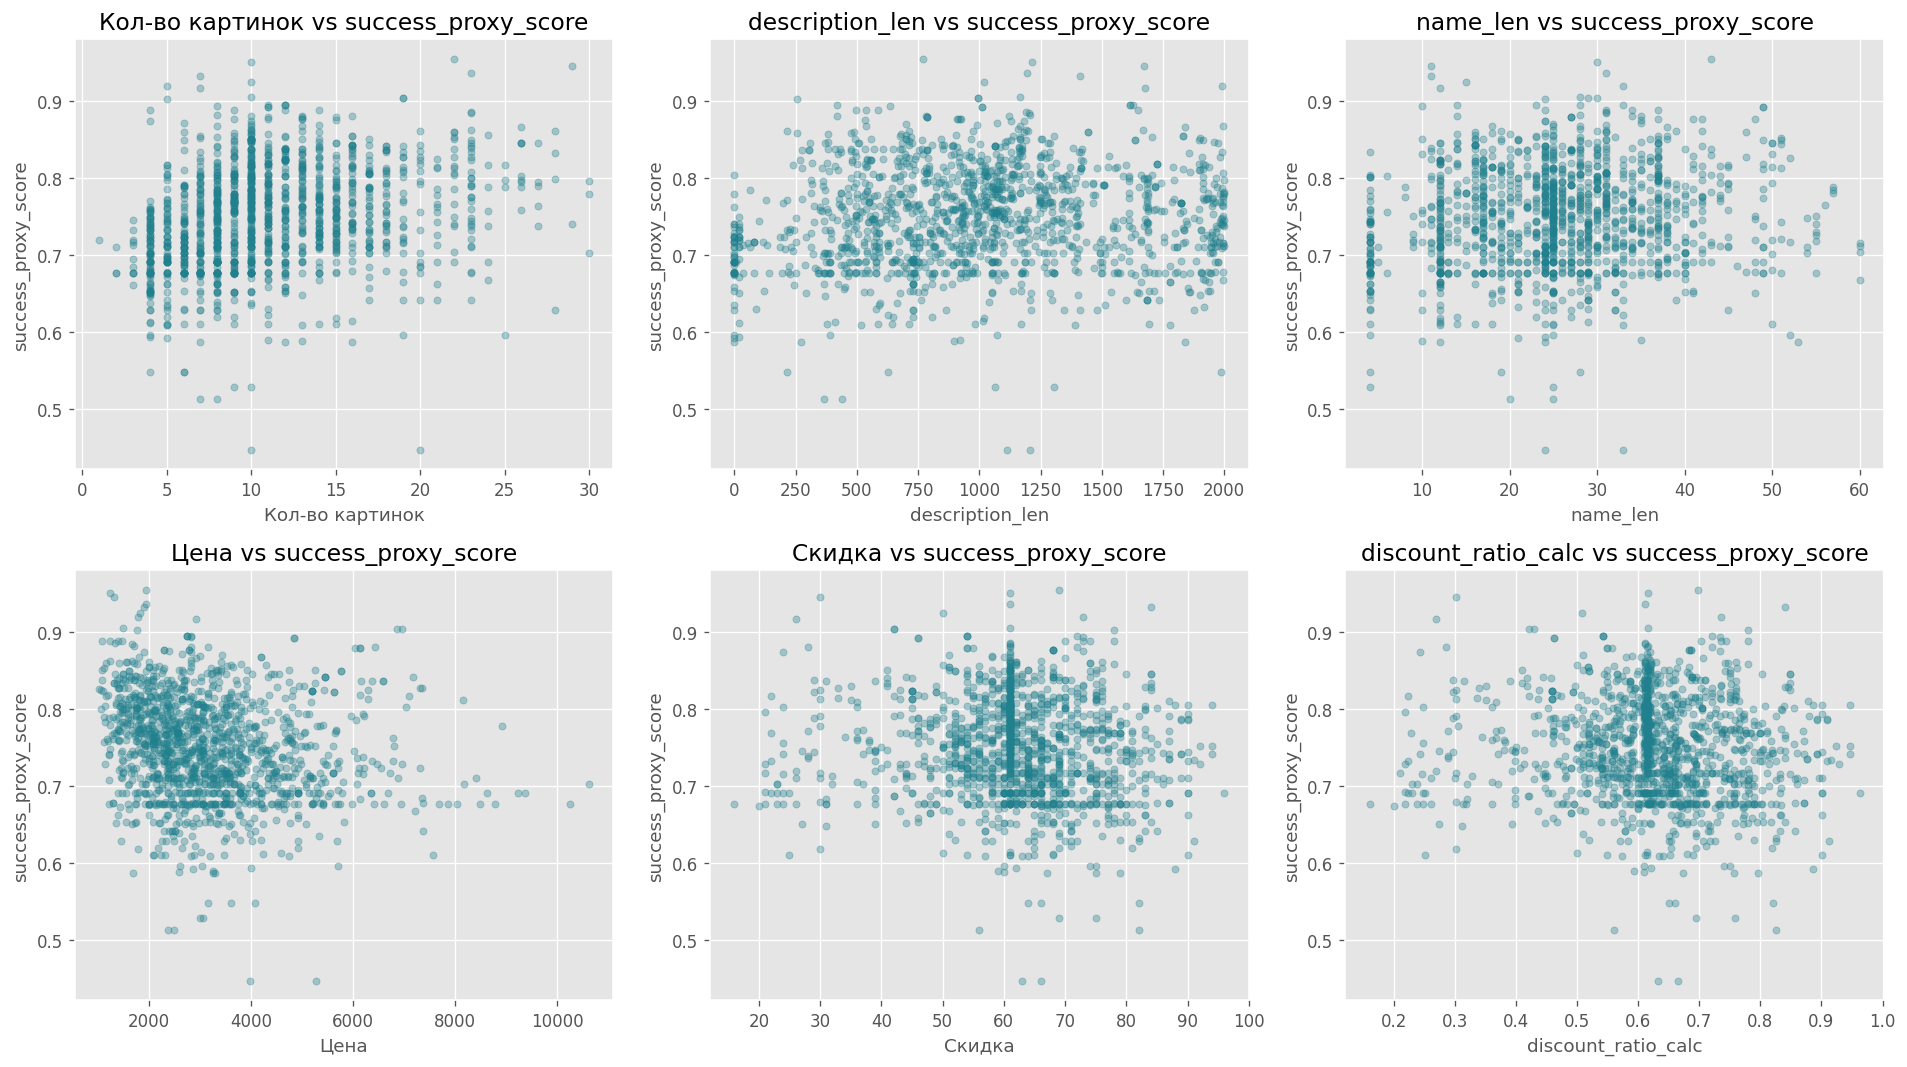

In [21]:
scatter_features = ["Кол-во картинок", "description_len", "name_len", "Цена", "Скидка", "discount_ratio_calc"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, col in enumerate(scatter_features):
    axes[i].scatter(
        supervised_df[col],
        supervised_df["success_proxy_score"],
        alpha=0.35,
        s=18,
        color=PALETTE["primary"],
    )
    axes[i].set_title(f"{col} vs success_proxy_score")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("success_proxy_score")

plt.tight_layout()
plt.show()

По результатам мы можем предположить, что раз `Кол-во картинок`, `has_video`, `has_rich_content` положительно коррелируют с `success_proxy_score`, это означает, что более успешные карточки чаще имеют более полное оформление.

## 7. Категориальные зависимости от таргет-метрики

Для категориальных признаков мы будем рассматривать среднюю таргет-метрику внутри каждой категории, то есть отличаются ли карточки одной категории от другой по успешности.

In [22]:
def target_mean_by_category(data: pd.DataFrame, col: str, min_count: int = 20) -> pd.DataFrame:
    report = (
        data
        .groupby(col, dropna=False)
        .agg(
            count=("success_proxy_score", "size"),
            target_mean=("success_proxy_score", "mean"),
            target_median=("success_proxy_score", "median"),
        )
        .reset_index()
        .sort_values("target_mean", ascending=False)
    )
    return report[report["count"] >= min_count]


categorical_for_target = [
    "has_video",
    "has_rich_content",
    "has_brand",
    "has_country",
    "Реклама",
    "Фулфилмент",
    "Доставка",
    "Сезон",
    "Категория",
    "Страна производства",
]

for col in categorical_for_target:
    print(f"\n{col}")
    display(target_mean_by_category(supervised_df, col, min_count=10).head(15))


has_video


,has_video,count,target_mean,target_median
1,1,428,0.770503,0.775118
0,0,1031,0.739784,0.737315



has_rich_content


,has_rich_content,count,target_mean,target_median
1,1,268,0.785407,0.789104
0,0,1191,0.740557,0.739584



has_brand


...

,Сезон,count,target_mean,target_median
3,Лето,200,0.774890,0.775451
2,Круглогодичный,319,0.762890,0.765476
0,Демисезон,336,0.756804,0.758535
13,NaN,162,0.741664,0.732979
10,лето,79,0.740005,0.742607
7,круглогодичный,166,0.728288,0.715954
4,демисезон,176,0.712128,0.708038



Категория


,Категория,count,target_mean,target_median
1,Обувь / Кроссовки,29,0.799456,0.812906
0,Обувь / Кеды,1430,0.747768,0.745857



Страна производства


,Страна производства,count,target_mean,target_median
5,Гонконг,135,0.785034,0.784116
4,Вьетнам,114,0.768765,0.770175
10,Китай,732,0.745111,0.742823
12,Россия,270,0.743976,0.740119
7,Индонезия,75,0.741453,0.732331
16,NaN,96,0.735304,0.727677


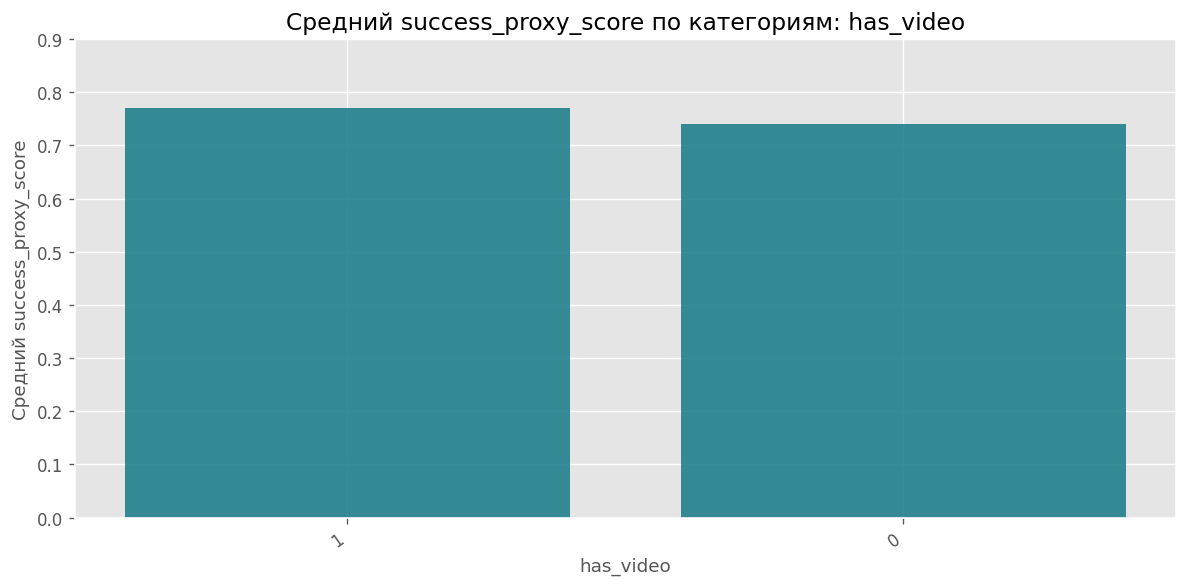

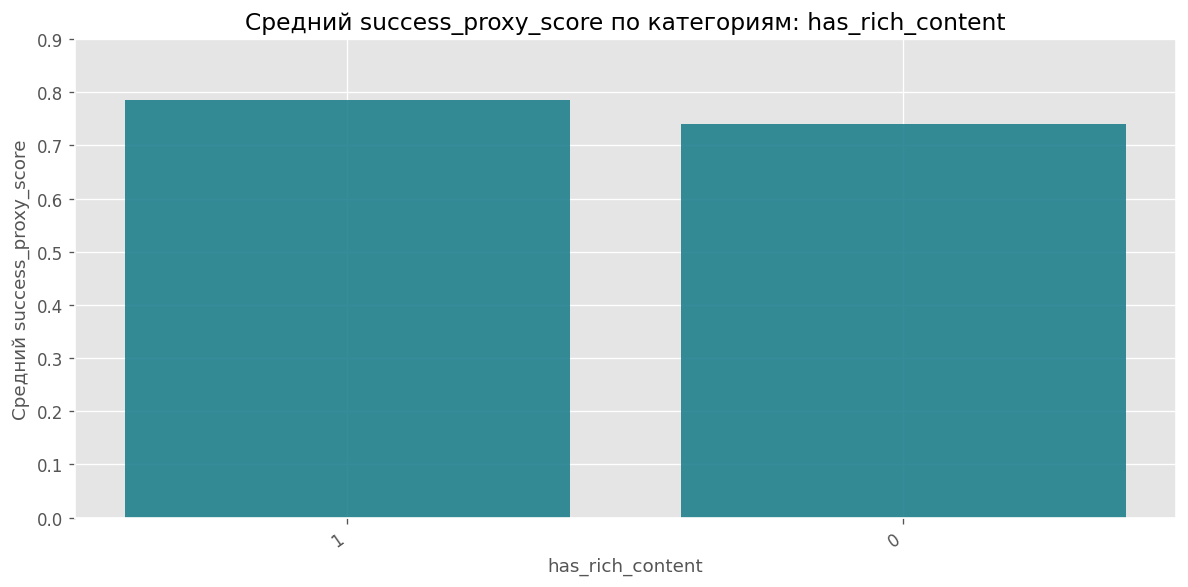

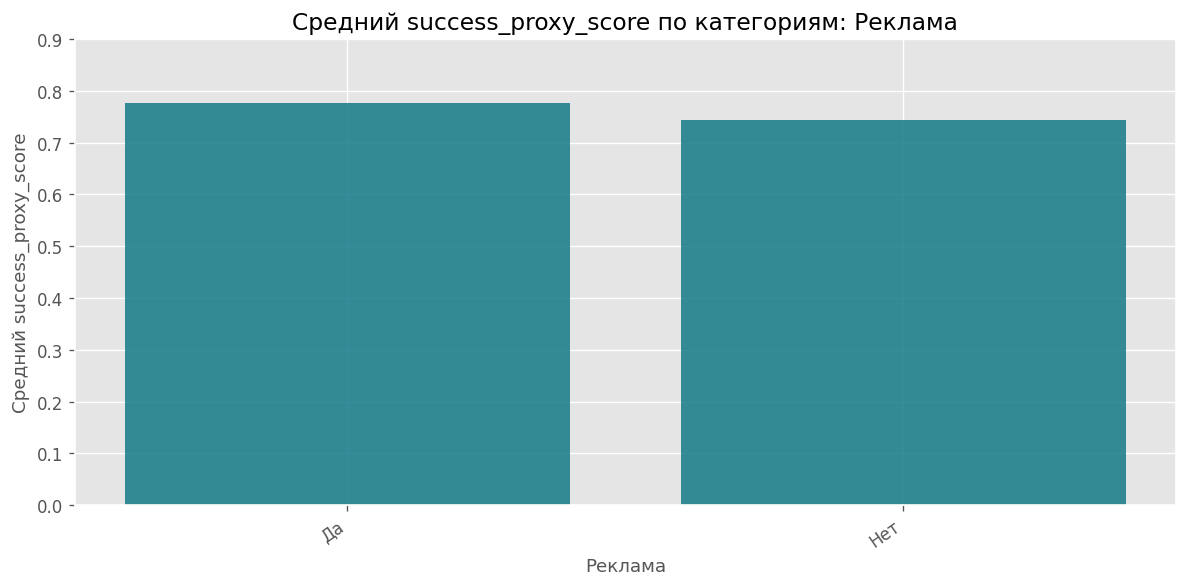

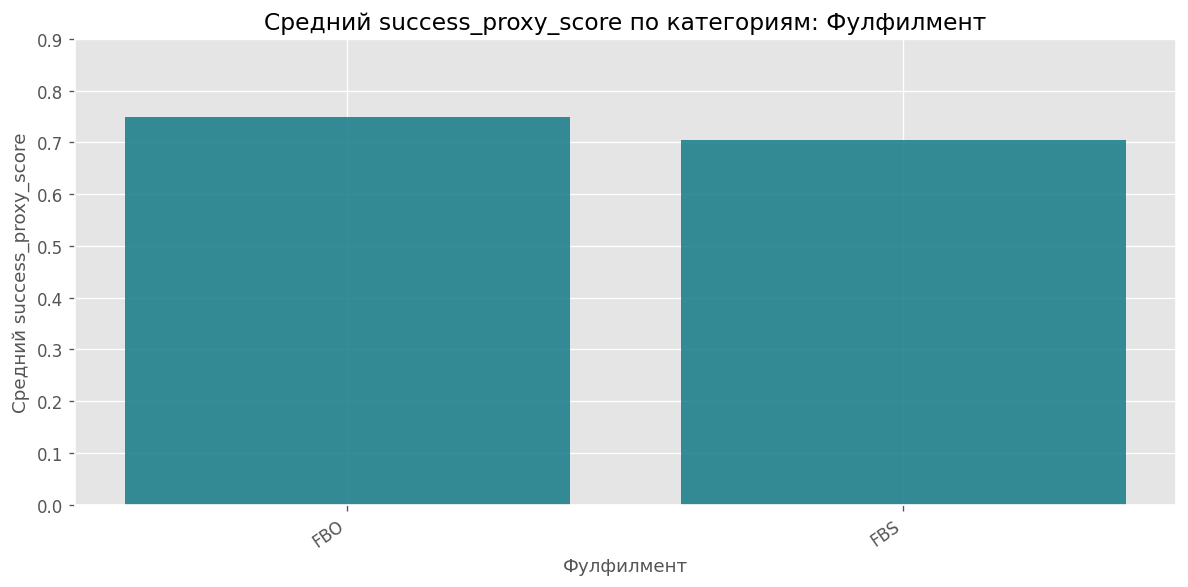

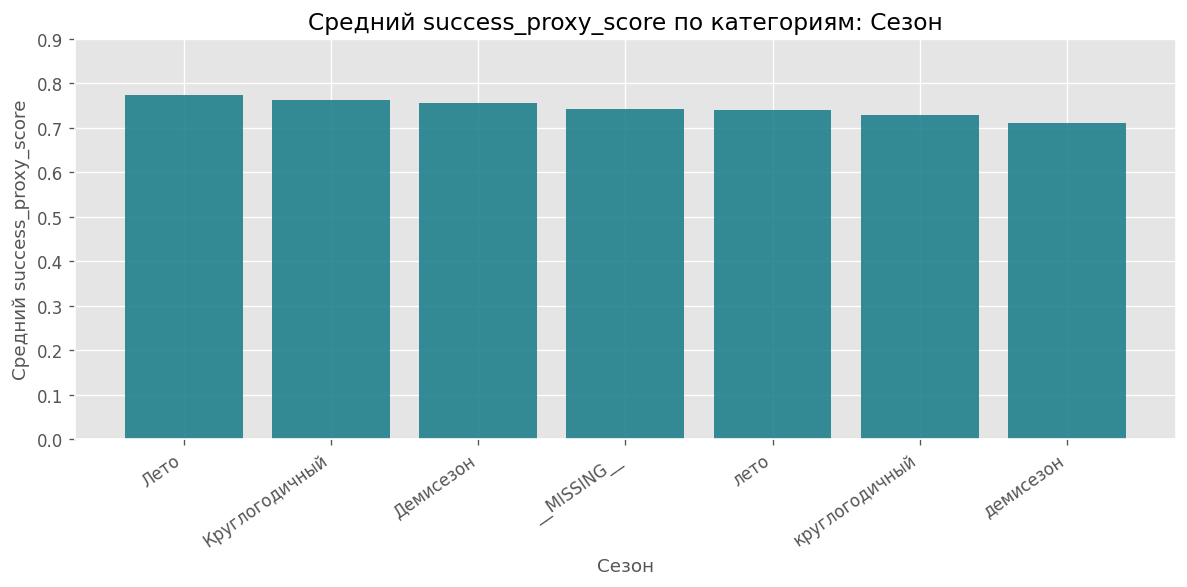

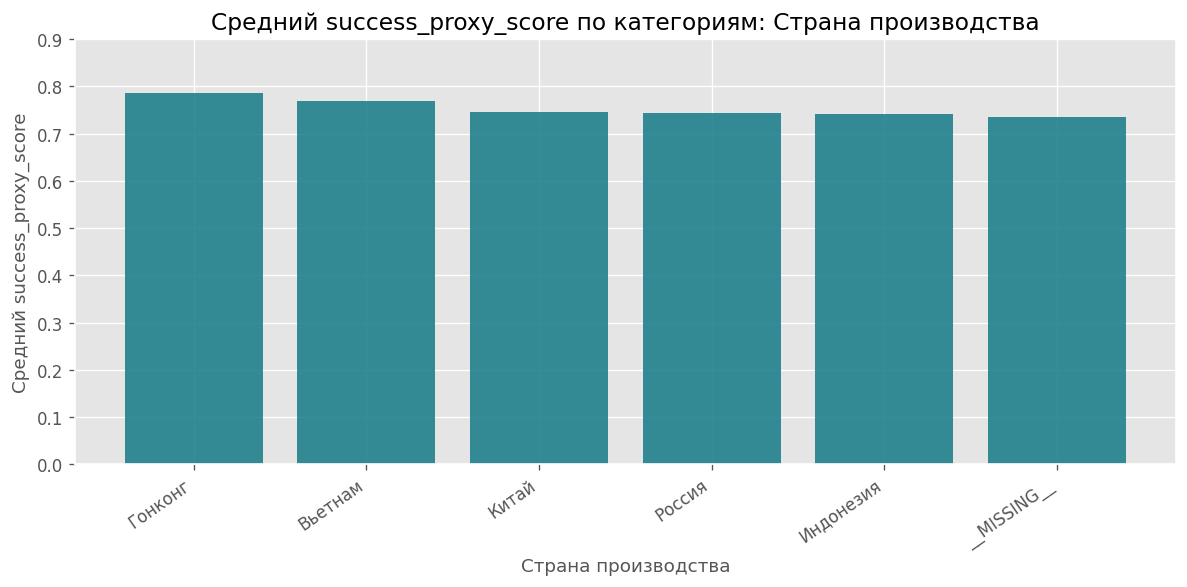

In [23]:
for col in ["has_video", "has_rich_content", "Реклама", "Фулфилмент", "Сезон", "Страна производства"]:
    report = target_mean_by_category(supervised_df, col, min_count=10).head(12)
    if report.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))
    labels = report[col].fillna("__MISSING__").astype(str)
    ax.bar(labels, report["target_mean"], color=PALETTE["primary"], alpha=0.9)
    ax.set_title(f"Средний success_proxy_score по категориям: {col}")
    ax.set_ylabel("Средний success_proxy_score")
    ax.set_xlabel(col)
    ax.set_ylim(0, min(1.0, max(0.9, report["target_mean"].max() * 1.1)))
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

## 8. Текстовые признаки

Текст в карточке также отражает полноту объявления, но сейчас мы не будем строить эмбеддинги, а будем рассматривать простые признаки:

- длина названия;
- число слов в названии;
- длина описания;
- число слов в описании;
- отсутствие описания.

In [24]:
text_bins = pd.qcut(
    supervised_df["success_proxy_score"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop",
)

text_summary = supervised_df.assign(success_bin=text_bins).groupby("success_bin")[
    ["name_len", "name_word_count", "description_len", "description_word_count", "description_missing"]
].agg(["mean", "median"])

text_summary

name_len        name_word_count        description_len          \
                  mean median            mean median            mean  median   
success_bin                                                                    
Q1           23.417112   24.0        3.430481    3.0      896.847594   807.0   
Q2           25.826331   25.0        3.652661    4.0      991.226891   956.0   
Q3           26.388430   25.0        3.727273    4.0     1072.322314  1052.0   
Q4           26.643836   26.0        3.873973    4.0     1035.364384  1022.0   

            description_word_count        description_missing         
                              mean median                mean median  
success_bin                                                           
Q1                      122.737968  112.0            0.077540    0.0  
Q2                      136.229692  131.0            0.039216    0.0  
Q3                      147.074380  141.0            0.005510    0.0  
Q4                      141.810959  140.0            0.002740    0.0

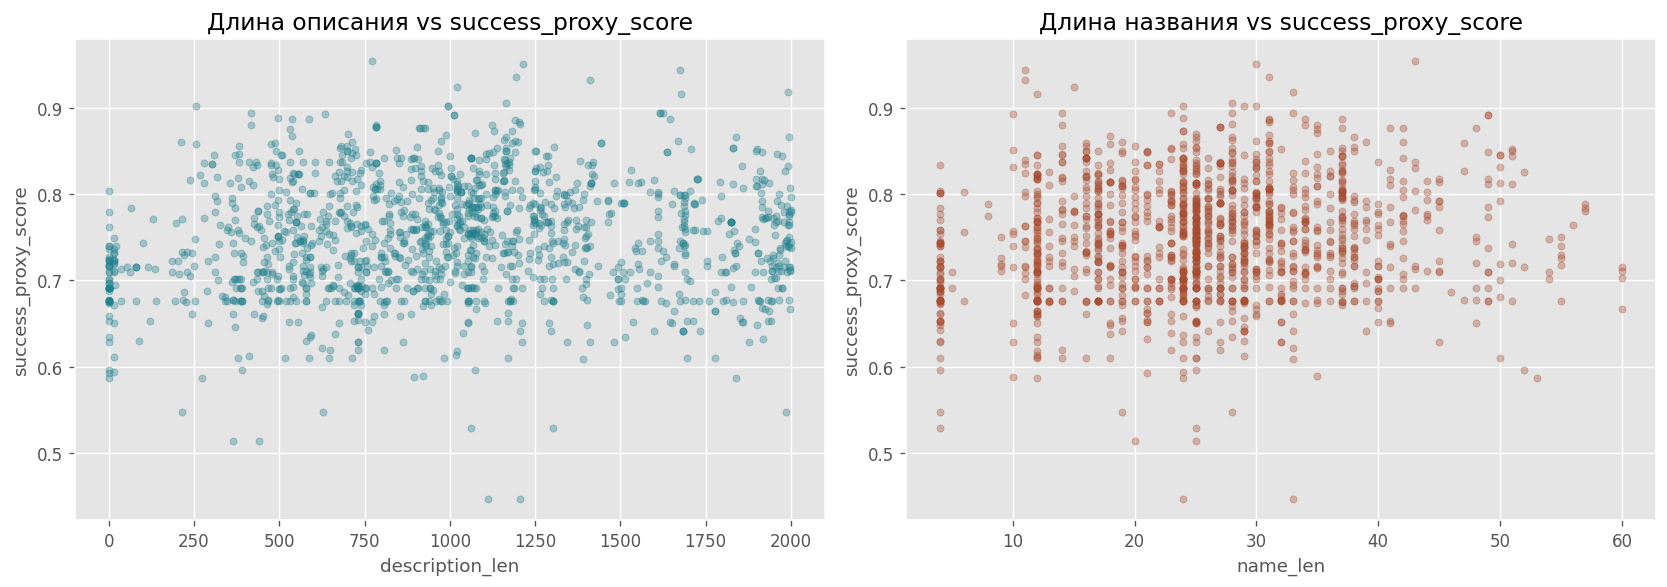

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(supervised_df["description_len"], supervised_df["success_proxy_score"], alpha=0.35, color=PALETTE["primary"], s=18)
axes[1].scatter(supervised_df["name_len"], supervised_df["success_proxy_score"], alpha=0.35, color=PALETTE["secondary"], s=18)

axes[0].set_title("Длина описания vs success_proxy_score")
axes[0].set_xlabel("description_len")
axes[0].set_ylabel("success_proxy_score")

axes[1].set_title("Длина названия vs success_proxy_score")
axes[1].set_xlabel("name_len")
axes[1].set_ylabel("success_proxy_score")

plt.tight_layout()
plt.show()

## 9. Избегание даталика

Следующие поля составляют таргет-метрику, поэтому подавать их в модель запрещено:

- `Рейтинг`;
- `Оценок`;
- `rating_norm`;
- `reviews_log1p`;
- `reviews_log_norm`;
- `success_proxy_score`.

Поля, являющиеся техническими id или URL, никак не влияют на успешность карточки.

Скрытые поля невозможно использовать для модели, потому что данные отсутствуют.

Оставшиеся поля можно использовать для обучения модели. 

## 10. Вывод

Следующие заключения по содержимому датасета:

1. Датасет содержит 4861 карточку и 41 колонку, валидных карточек: 1459.
2. Таргет можно построить только для строк, где есть `Рейтинг` и `Оценок`.
3. `Рейтинг` и `Оценок` формируют таргет, поэтому мы не подаем их в модель.
6. Самые перспективные безопасные признаки по EDA: `Кол-во картинок`, `has_video`, `has_rich_content`, `Реклама`, длина описания, длина названия, бренд, страна производства.